# PROJECT: CUSTOMER TRANSACTION PREDICTION 
### PROJECT TYPE
Machine learning - Classification
### DOMAIN
Banking
### BUSINESS CONTEXT
Banks want to identify customers who are likely to make transactions in the future. This helps improve marketing ,customer engagement,and business decisions.
### PROBLEM STATEMENT
Build a Machine Learning model to predict whether a customer will make a future transaction.

* 1 → Will make transaction
* 0 → Will not make transaction
### PROJECT OBJECTIVE
* Identify patterns influencing customer transactions
* Predict whether a customer is likely to make a transaction
* Create a binary target variable (1 = Yes, 0 = No)
* Compare different Machine Learning models
* Select the best-performing model for prediction
* Support better business and marketing decision

### Data Understanding
#### Data Source
The dataset used in this project was collected from banking customer transaction records.

#### Target Variable
target (0 / 1)
#### Features Include
1. Customer transaction-related numerical features
2. Anonymous variables such as:
   - var_0
   - var_1
   - var_2
   - up to var_199
3. Customer identification column:
   - ID_code
Target Variable Description:
- 0 → Customer will not make a transaction
- 1 → Customer will make a transaction



## IMPORT REQUIRED LIBRARIES

In [2]:
# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,recall_score,confusion_matrix,classification_report,ConfusionMatrixDisplay

# models 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# warnings
import warnings
warnings.filterwarnings('ignore')




## DATA LOADING
The dataset contains customer-level banking transaction information such as:
* Customer transaction-related features
* Numerical banking variables
* Anonymized feature columns
* Transaction status (target variable)
The data is loaded and inspected for structure, completeness, and data types before preprocessing and model building.

In [3]:
df=pd.read_csv('PRCP-1003-CustTransPred.zip')
df

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,train_199995,0,11.4880,-0.4956,8.2622,3.5142,10.3404,11.6081,5.6709,15.1516,...,6.1415,13.2305,3.9901,0.9388,18.0249,-1.7939,2.1661,8.5326,16.6660,-17.8661
199996,train_199996,0,4.9149,-2.4484,16.7052,6.6345,8.3096,-10.5628,5.8802,21.5940,...,4.9611,4.6549,0.6998,1.8341,22.2717,1.7337,-2.1651,6.7419,15.9054,0.3388
199997,train_199997,0,11.2232,-5.0518,10.5127,5.6456,9.3410,-5.4086,4.5555,21.5571,...,4.0651,5.4414,3.1032,4.8793,23.5311,-1.5736,1.2832,8.7155,13.8329,4.1995
199998,train_199998,0,9.7148,-8.6098,13.6104,5.7930,12.5173,0.5339,6.0479,17.0152,...,2.6840,8.6587,2.7337,11.1178,20.4158,-0.0786,6.7980,10.0342,15.5289,-13.9001


## DATA UNDERSTANDING

In [4]:
#  view first rows
df.head()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [5]:
# view last rows
df.tail()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
199995,train_199995,0,11.4880,-0.4956,8.2622,3.5142,10.3404,11.6081,5.6709,15.1516,...,6.1415,13.2305,3.9901,0.9388,18.0249,-1.7939,2.1661,8.5326,16.6660,-17.8661
199996,train_199996,0,4.9149,-2.4484,16.7052,6.6345,8.3096,-10.5628,5.8802,21.5940,...,4.9611,4.6549,0.6998,1.8341,22.2717,1.7337,-2.1651,6.7419,15.9054,0.3388
199997,train_199997,0,11.2232,-5.0518,10.5127,5.6456,9.3410,-5.4086,4.5555,21.5571,...,4.0651,5.4414,3.1032,4.8793,23.5311,-1.5736,1.2832,8.7155,13.8329,4.1995
199998,train_199998,0,9.7148,-8.6098,13.6104,5.7930,12.5173,0.5339,6.0479,17.0152,...,2.6840,8.6587,2.7337,11.1178,20.4158,-0.0786,6.7980,10.0342,15.5289,-13.9001
199999,train_199999,0,10.8762,-5.7105,12.1183,8.0328,11.5577,0.3488,5.2839,15.2058,...,8.9842,1.6893,0.1276,0.3766,15.2101,-2.4907,-2.2342,8.1857,12.1284,0.1385


In [6]:
# dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 202 entries, ID_code to var_199
dtypes: float64(200), int64(1), object(1)
memory usage: 308.2+ MB


In [7]:
# statical summary
df.describe()

,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,0.100490,10.679914,-1.627622,10.715192,6.796529,11.078333,-5.065317,5.408949,16.545850,0.284162,...,3.234440,7.438408,1.927839,3.331774,17.993784,-0.142088,2.303335,8.908158,15.870720,-3.326537
std,0.300653,3.040051,4.050044,2.640894,2.043319,1.623150,7.863267,0.866607,3.418076,3.332634,...,4.559922,3.023272,1.478423,3.992030,3.135162,1.429372,5.454369,0.921625,3.010945,10.438015
min,0.000000,0.408400,-15.043400,2.117100,-0.040200,5.074800,-32.562600,2.347300,5.349700,-10.505500,...,-14.093300,-2.691700,-3.814500,-11.783400,8.694400,-5.261000,-14.209600,5.960600,6.299300,-38.852800
25%,0.000000,8.453850,-4.740025,8.722475,5.254075,9.883175,-11.200350,4.767700,13.943800,-2.317800,...,-0.058825,5.157400,0.889775,0.584600,15.629800,-1.170700,-1.946925,8.252800,13.829700,-11.208475
50%,0.000000,10.524750,-1.608050,10.580000,6.825000,11.108250,-4.833150,5.385100,16.456800,0.393700,...,3.203600,7.347750,1.901300,3.396350,17.957950,-0.172700,2.408900,8.888200,15.934050,-2.819550
75%,0.000000,12.758200,1.358625,12.516700,8.324100,12.261125,0.924800,6.003000,19.102900,2.937900,...,6.406200,9.512525,2.949500,6.205800,20.396525,0.829600,6.556725,9.593300,18.064725,4.836800
max,1.000000,20.315000,10.376800,19.353000,13.188300,16.671400,17.251600,8.447700,27.691800,10.151300,...,18.440900,16.716500,8.402400,18.281800,27.928800,4.272900,18.321500,12.000400,26.079100,28.500700


## Observations
* The dataset contains 200000 records and 202 columns with no missing values
* Target variable is categorical with binary values (0 and 1)
* Dataset contains mostly numerical features and one categorical feature (ID_code)
* ID_code is a unique identifier column and not useful for prediction
* Data quality is good and suitable for Machine Learning modeling
* Correlation analysis is used to understand feature relationships
* Dataset is suitable for classification algorithms for transaction prediction

## DATA PREPROCESSING

In [8]:
# check missing values
df.isnull().sum()

ID_code    0
target     0
var_0      0
var_1      0
var_2      0
          ..
var_195    0
var_196    0
var_197    0
var_198    0
var_199    0
Length: 202, dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
# check data types
df.dtypes

ID_code     object
target       int64
var_0      float64
var_1      float64
var_2      float64
            ...   
var_195    float64
var_196    float64
var_197    float64
var_198    float64
var_199    float64
Length: 202, dtype: object

In [11]:
#Drop Unnecessary Column-->ID_code is not useful for prediction.
df.drop('ID_code',axis=1,inplace=True)

## EXPLORATORY DATA ANALYSIS(EDA)


In [12]:
# Target column analysis
df['target'].value_counts()

target
0    179902
1     20098
Name: count, dtype: int64

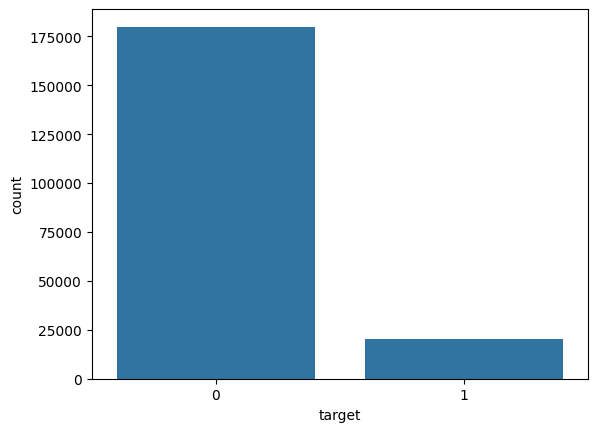

In [13]:
# countplot-->  this shows class distribution
sns.countplot(x='target',data=df)
plt.show()

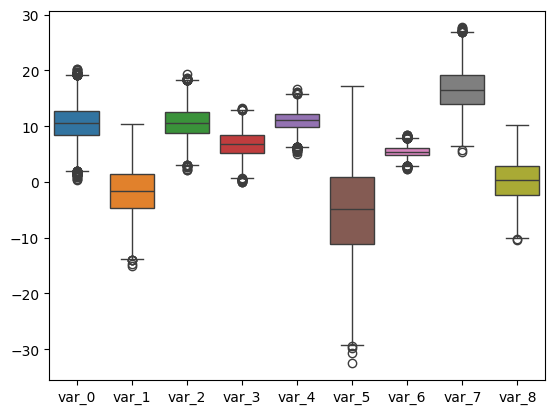

In [14]:
# box plot for outlier detection
sns.boxplot(data=df.iloc[:,1:10])
plt.show()

## FEATURE AND TARGET SEPARATION 

In [15]:
#Seperate independent and dependent variables.
x=df.drop('target',axis=1)
y=df['target']

In [16]:
#Split data into train and testing datasets.
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [17]:
# Normalize feature value by using standardscaller.
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.fit_transform(x_test)

## MODEL BUILDING
#### Logistic Regression

In [18]:
lr=LogisticRegression()
lr.fit(x_train,y_train)
y_pred_lr=lr.predict(x_test)

#### Decision Tree

In [19]:
dt=DecisionTreeClassifier(random_state=42)
dt.fit(x_train,y_train)
y_pred_dt=dt.predict(x_test)

#### Random forest

In [20]:
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(x_train,y_train)
y_pred_rf=rf.predict(x_test)

#### XGBoost

In [21]:
xgb=XGBClassifier()
xgb.fit(x_train,y_train)
y_pred_xgb=xgb.predict(x_test)

## Model Evaluation
#### Accuracy Score

In [22]:
accuracy_score(y_test,y_pred_rf)

0.8976

#### Confusion Matric

In [23]:
cm=confusion_matrix(y_test,y_pred_rf)
print(cm)

[[35903     0]
 [ 4096     1]]


#### Display Confusion Matrix

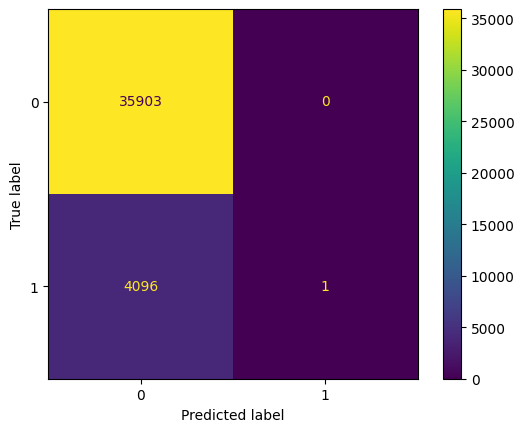

In [24]:
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

#### Classification Report

In [25]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95     35903
           1       1.00      0.00      0.00      4097

    accuracy                           0.90     40000
   macro avg       0.95      0.50      0.47     40000
weighted avg       0.91      0.90      0.85     40000



#### Model Comparision

In [26]:
models=pd.DataFrame({'model':['Logistic Regression','Decision Tree','Random Forest','XGBoost'],'Accuracy':[accuracy_score(y_test,y_pred_lr),accuracy_score(y_test,y_pred_dt),accuracy_score(y_test,y_pred_rf),accuracy_score(y_test,y_pred_xgb)]})
models

,model,Accuracy
0,Logistic Regression,0.913075
1,Decision Tree,0.834000
2,Random Forest,0.897600
3,XGBoost,0.910600


#### Accuracy Visualizaation

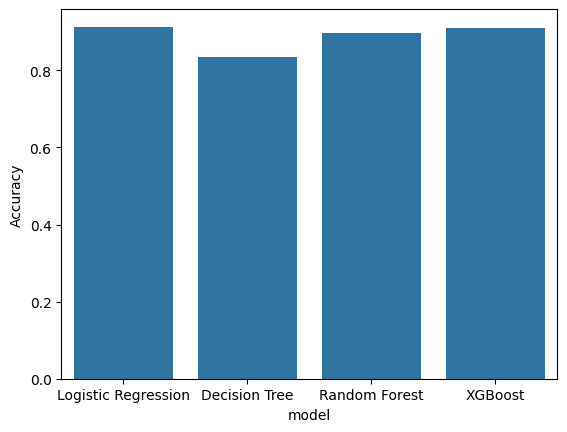

In [27]:
sns.barplot(x='model',y='Accuracy',data=models)
plt.show()

#### Model Comparison Report

In this project, multiple Machine Learning classification models were implemented and evaluated for Customer Transaction Prediction. The models used were Logistic Regression, Decision Tree, Random Forest, and XGBoost.

The performance of the models was evaluated using Accuracy Score, Confusion Matrix, Recall, and F1-score.

1. Logistic Regression
Logistic Regression achieved the best overall performance among all models. It handled the large dataset efficiently and provided stable prediction results. The model performed well for binary classification and achieved the highest accuracy.

2. Decision Tree
Decision Tree achieved lower accuracy compared to the other models. The model showed signs of overfitting and was less effective in handling the imbalanced dataset.

3. Random Forest
Random Forest improved performance compared to Decision Tree because it uses ensemble learning. It reduced overfitting and provided better prediction accuracy, but its performance was slightly lower than Logistic Regression.

4. XGBoost
XGBoost also produced good prediction results and handled the dataset effectively. It improved model learning using boosting techniques and reduced overfitting. However, Logistic Regression achieved slightly better overall performance in this project.

After comparing all models, Logistic Regression was selected as the final model because it achieved the highest accuracy and best overall performance for customer transaction prediction.

#### Best Model Selection
* Logistic Regression achieved the highest accuracy among all models.
* Therefore, Logistic Regression is selected as the best model for customer transaction prediction.

#### Report on Challenges Faced

Several challenges were faced during the development of the Customer Transaction Prediction project.

1. Anonymous Feature Names
The dataset contained anonymous feature names such as var_0, var_1, etc. This made it difficult to understand the business meaning of the features and perform detailed domain analysis.

Technique Used:
Basic Exploratory Data Analysis (EDA) and correlation analysis were performed to understand data patterns and relationships.

2. Imbalanced Dataset
The target column contained more class 0 values than class 1 values. Because of this imbalance, some models predicted majority class values more frequently.

Technique Used:
Metrics such as Recall, F1-score, and Confusion Matrix were used along with Accuracy Score to properly evaluate model performance. Logistic Regression with class balancing was also applied.

3. Large Number of Features
The dataset contained 200 numerical features, increasing model complexity and training time.

Technique Used:
Feature scaling using StandardScaler was applied to normalize the data and improve model performance.

4. Model Overfitting
Decision Tree model showed signs of overfitting compared to other models.

Technique Used:
Random Forest and XGBoost were used because ensemble learning techniques help reduce overfitting and improve prediction accuracy.

5. Computational Time
Training Machine Learning models on a large dataset required more processing time and system resources.

Technique Used:
Efficient Machine Learning algorithms and train-test split techniques were used to optimize training and evaluation performance.

#### Conclusion

In this project, Customer Transaction Prediction was performed using Machine Learning techniques. Data preprocessing and basic Exploratory Data Analysis (EDA) were completed to understand and clean the dataset. Multiple classification algorithms such as Logistic Regression, Decision Tree, and Random Forest were implemented and evaluated.

The models were compared using Accuracy Score, Confusion Matrix, Recall, and F1-score. Among all models, Logistic Regression achieved the best overall performance with the highest accuracy.

The project successfully predicts whether a customer is likely to make a transaction in the future. This model can help banks identify potential customers and support better business decision-making.